Mahan Madani - 830504035

## Table of Contents

- [Import Libraries and Configs](#import-libraries-and-configs)
- [Sample Images From the Test and Train Dataset](#sample-images-from-the-test-and-train-dataset)
- [Generate Captions for Sample Images](#generate-captions-for-sample-images)
    - [FusionVLM Sample Captions](#fusionvlm-sample-captions)
    - [BLIP Sample Captions](#blip-sample-captions)
- [Evaluate Models on the Test Dataset](#evaluate-models-on-the-test-dataset)
    - [Evaluate FusionVLM on the Test Data](#evaluate-fusionvlm-on-the-test-data)
    - [Evaluate BLIP on the Test Data](#evaluate-blip-on-the-test-data)

## Import libraries and Configs

In [1]:
import torch
import matplotlib.pyplot as plt
from transformers import T5TokenizerFast, CLIPImageProcessorFast
from transformers import BlipProcessor, BlipForConditionalGeneration

In [2]:
from Modules.inference import caption_image_FusionVLM, caption_image_BLIP, load_image
from Modules.FusionVLM import load_default_FusionVLM
from Modules.retrieval_module import Retriever
from Modules.embedding_module import Embedder
from Modules.utils import display_image
from Modules.config import *
from Modules.metrics import evaluate_captioning


In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

## Sample Images From the Test and Train Dataset

In [10]:
def display_images(images, title):    
    n = len(images)
    plt.figure(figsize=(12, 4))

    for i in range(n):
        plt.subplot(1, n, i+1)
        image = images[i]
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"{title} {i+1}")

    plt.tight_layout()
    plt.show()

In [12]:
test_img_1 = '211295363.jpg'
test_img_2 = '6892090337.jpg'
test_img_3 = '4242784332.jpg'

train_img_1 = '10404007.jpg'
train_img_2 = '26758039.jpg'
train_img_3 = '54501196.jpg'

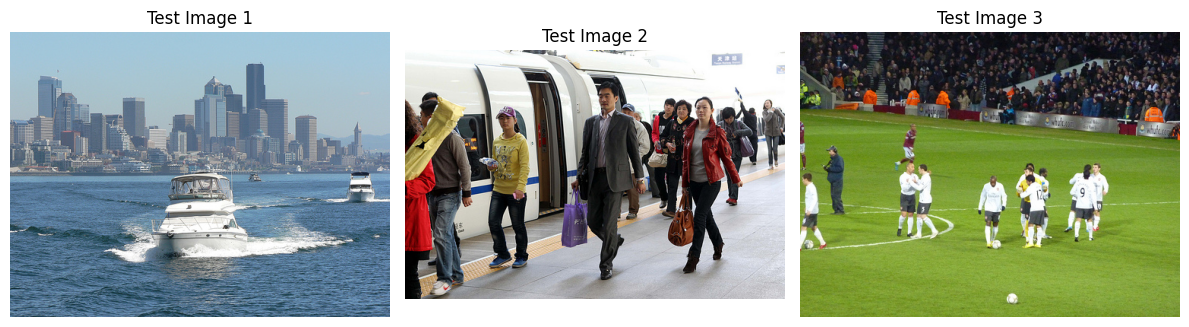

In [ ]:
query1 = load_image(test_img_1, TEST_IMAGE_DIR)
query2 = load_image(test_img_2, TEST_IMAGE_DIR)
query3 = load_image(test_img_3, TEST_IMAGE_DIR)
query_test = [query1, query2, query3]

display_images(query_test, "Test Image")

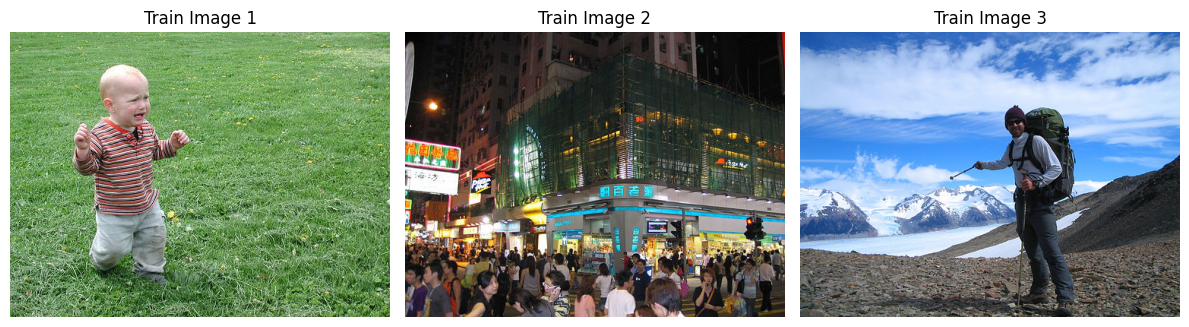

In [14]:
query1 = load_image(train_img_1, TRAIN_IMAGE_DIR)
query2 = load_image(train_img_2, TRAIN_IMAGE_DIR)
query3 = load_image(train_img_3, TRAIN_IMAGE_DIR)
query_train = [query1, query2, query3]

display_images(query_train, "Train Image")

## Generate Captions for Sample Images

Initialize FusionVLM model and components

In [7]:
fusionVLM_model = load_default_FusionVLM('epoch20', use_local_files=True).to(DEVICE)
# fusionVLM_model = load_default_FusionVLM('epoch10', use_local_files=True).to(DEVICE)
embedder = Embedder(CLIP_MODEL_NAME, use_local_files=True, device=DEVICE)

CLIP_processor = CLIPImageProcessorFast.from_pretrained(CLIP_MODEL_NAME, local_files_only=True)
T5_tokenizer = T5TokenizerFast.from_pretrained(T5_MODEL_NAME, local_files_only=True)

image_retriever = Retriever(faiss_path=FAISS_IMAGE_PATH, metadata_path=TRAIN_METADATA_PATH)
caption_retriever = Retriever(faiss_path=FAISS_CAPTION_PATH, metadata_path=CAPTION_METADATA_PATH)

Initialize BLIP model and components

In [8]:
BLIP_processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME, local_files_only=True, use_fast=True)
BLIP_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_NAME, local_files_only=True).to(DEVICE)

### FusionVLM Sample Captions

In [ ]:
fusionVLM_captions_train = caption_image_FusionVLM(query=query_train, model=fusionVLM_model, embedder=embedder, processor=CLIP_processor, tokenizer=T5_tokenizer, 
                        image_retriever=image_retriever, caption_retriever=caption_retriever, ref_image_dir=TRAIN_IMAGE_DIR, device=DEVICE)
fusionVLM_captions_train

['A picture of a little boy on a sunny day .',
 'A picture of a man in a white shirt is walking in front of a building .',
 'A picture of hikers in the mountains .']

In [ ]:
fusionVLM_captions_test = caption_image_FusionVLM(query=query_test, model=fusionVLM_model, embedder=embedder, processor=CLIP_processor, tokenizer=T5_tokenizer, 
                        image_retriever=image_retriever, caption_retriever=caption_retriever, ref_image_dir=TRAIN_IMAGE_DIR, device=DEVICE)
fusionVLM_captions_test

['A picture of on a sunny day with a boat in the background .',
 'A picture of a man and a woman are walking down the street .',
 'A picture of soccer players in a stadium .']

### BLIP Sample Captions

In [ ]:
blip_captions_train = caption_image_BLIP(query_train, BLIP_model, BLIP_processor, DEVICE)
blip_captions_train

['a small child standing in a field of grass',
 'a crowd of people walking on a busy street at night',
 'a man with a backpack']

In [ ]:
blip_captions_test = caption_image_BLIP(query_test, BLIP_model, BLIP_processor, DEVICE)
blip_captions_test

['a large body of water',
 'a group of people sitting at a table eating',
 'a group of people on a soccer field']

## Evaluate Models on the Test Dataset

In [ ]:
from Modules.datasets import Flickr30kVLMDataset, VLMDataCollator, BLIPImageDataCollator
from torch.utils.data import DataLoader

train_retriever = Retriever(metadata_path=TRAIN_METADATA_PATH, faiss_path=FAISS_IMAGE_PATH)
test_retriever = Retriever(metadata_path=TEST_METADATA_PATH, faiss_path=FAISS_IMAGE_PATH)

test_dataset = Flickr30kVLMDataset(image_dir=TEST_IMAGE_DIR, 
                           ref_image_dir=TRAIN_IMAGE_DIR,
                           retriever=test_retriever,
                           reference_retriever=train_retriever)

collator_fusionVLM = VLMDataCollator(CLIP_processor, T5_tokenizer, device=DEVICE)
collator_blip = BLIPImageDataCollator(BLIP_processor, device=DEVICE)

BATCH_SIZE = 16
NUM_WORKERS = 0

test_loader_fusionVLM = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator_fusionVLM)
test_loader_blip = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collator_blip)

### Evaluate FusionVLM on the Test Data

In [11]:
fusionVLM_model.eval()
preds = []
refs = []

with torch.no_grad():
    for batch in test_loader_fusionVLM:
        gt_captions = batch.get("all_captions")  # List[List[str]]

        generated_ids = fusionVLM_model.generate(
                query_pixel_values=batch.get("query_pixel_values"),
                retrieved_pixel_values=batch.get("retrieved_pixel_values"),
                input_ids=batch.get("input_ids"),
                attention_mask=batch.get("attention_mask"),
                max_length=64,
                do_sample=False,
                early_stopping=True,
                length_penalty=1.2, # longer outputs 
                repetition_penalty=1.2 # penalize repeats
        )
        
        decoded = T5_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        preds.extend(decoded)
        refs.extend(gt_captions)

metrics_fusionVLM = evaluate_captioning(preds, refs)


In [15]:
print("FusionVLM evaluation results:")
for k, v in metrics_fusionVLM.items():
    print(f"{k}: {v:.4f}")

FusionVLM evaluation results:
BLEU-1: 0.6614
BLEU-2: 0.4960
BLEU-3: 0.3823
BLEU-4: 0.2899
METEOR: 0.4842
ROUGE-L: 0.5138
CIDEr: 0.3072


### Evaluate BLIP on the Test Data

In [ ]:
BLIP_model.eval()
preds = []
refs = []

with torch.no_grad():
    for batch in test_loader_blip:
        gt_captions = batch.get("all_captions")  # List[List[str]]

        generated_ids = BLIP_model.generate(
                pixel_values=batch.get("query_pixel_values"),
                max_length=64,
                do_sample=False,
                # early_stopping=True, # (invalid for blip)
                # length_penalty=1.2, # longer outputs (invalid for blip)
                repetition_penalty=1.2 # penalize repeats
        )
        
        decoded = BLIP_processor.batch_decode(generated_ids, skip_special_tokens=True)
        preds.extend(decoded)
        refs.extend(gt_captions)

metrics_blip = evaluate_captioning(preds, refs)

In [20]:
print("BLIP evaluation results:")
for k, v in metrics_blip.items():
    print(f"{k}: {v:.4f}")

BLIP evaluation results:
BLEU-1: 0.3253
BLEU-2: 0.2462
BLEU-3: 0.1759
BLEU-4: 0.1183
METEOR: 0.2672
ROUGE-L: 0.4204
CIDEr: 0.2539
